In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
data = pd.read_csv('Gaming_PC_Performance.csv')

In [11]:
mask = np.random.rand(len(data)) < 0.8
train = data[mask]
test = data[~mask]

print(f"percentage= train: {(len(train)/len(data))*100} test: {(len(test)/len(data))*100}")

percentage= train: 83.71428571428572 test: 16.28571428571429


In [18]:
fpsAI = linear_model.LinearRegression()

In [17]:
train_x = np.asanyarray(train[['GPU_VRAM_GB','RAM_GB','RESOLUTION_PX']])
train_y = np.asanyarray(train[['AVG_FPS']])

In [19]:
fpsAI.fit(train_x,train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 3)","[[ 6.37, 0.44,-0. ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[1.47]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[34180654.45, 289.65, 77.5 ]"


In [20]:
print(f"coef_: {fpsAI.coef_} intercept_: {fpsAI.intercept_}")

coef_: [[ 6.37226877e+00  4.42095265e-01 -7.97151237e-06]] intercept_: [1.47443528]


In [21]:
test_x = np.asanyarray(test[['GPU_VRAM_GB','RAM_GB','RESOLUTION_PX']])
test_y = np.asanyarray(test[['AVG_FPS']])

In [22]:
test_y_out = fpsAI.predict(test_x)

Text(0, 0.5, 'Predicted FPS')

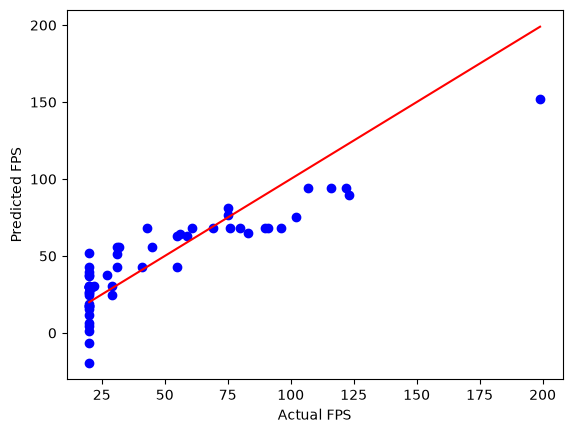

In [ ]:
plt.scatter(test_y, test_y_out, color='blue')
plt.plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()], '-r')
plt.xlabel("Actual FPS")
plt.ylabel("Predicted FPS")

In [25]:
mae_abs = np.abs(test_y- test_y_out)
mae = np.mean(mae_abs)

squared = np.square(test_y - test_y_out)
mse = np.mean(squared)

r2_mean = np.mean(test_y)
ss_res = np.sum((test_y - test_y_out) ** 2)
ss_tot = np.sum((test_y - r2_mean) ** 2)

r2 = 1 - (ss_res / ss_tot)

In [26]:
print(f"""mae : {mae}
mse: {mse}
R2: {r2}""")

mae : 14.057328916697042
mse: 302.7484964045909
R2: 0.7830063898622066


###### the old R2 was around 0.35 i guess but now we're reaching 0.7 so we improved our guesses using multi linear regression instead of simple linear regression, for the ping and hours played that you said, those are just noise so im not gonna add them to my model cause i already know those doesnt have any relations with avg fps.

In [37]:
gpu_vram = 12
ram_gb = 32
resolution = 2073600
answer = fpsAI.intercept_[0] + fpsAI.coef_[0][0] * gpu_vram + fpsAI.coef_[0][1] * ram_gb + fpsAI.coef_[0][2] * resolution

print(f"the avg gonna be: {answer}")

the avg gonna be: 75.55898100001532


###### i used the exact same gpu vram that i gave to the previous model , in the previous model we had 59 fps but now we have 75 fps, so the model got improved as we can tell with the better r2